---
title: "Site Utilisation"
toc: true
execute:
  enabled: true
image: image.png
---

Every method in the [2SFCA example](../accessibility_2sfca/index.ipynb) and `site_allocation_summary()` (see the [comparing N sites example](../comparing_n_sites/index.ipynb)) answers a question about *reachable* or *allocated* supply -- how much supply is available given competition from other regions' demand, or how much demand a site would pick up under a solved solution. Both need a travel matrix, and the latter needs a solved solution.

This example answers a different, simpler question: **is this site already full *today*?** `site_utilisation_summary()` and `plot_site_utilisation()` report a site's real-world current load against its capacity, using only `candidate_sites` -- no demand data, no travel matrix, and no `solve()` required. It's a baseline diagnostic, not a model output.

## Setting up the problem

Same six Brighton sites as the [2SFCA example](../accessibility_2sfca/index.ipynb). The sample dataset has no real staffing or activity data, so as with that example's illustrative `gp_fte` column, we add two made-up columns here for demonstration: `weekly_capacity` (appointment slots per week) and `weekly_caseload` (slots actually booked). We'll imagine this is an average over the last 24 weeks. 

`add_sites(current_load_col=..., capacity_col=...)` registers both -- `current_load_col` always needs `capacity_col` alongside it, since a raw count on its own can't be turned into a ratio.

In [1]:
import geopandas as gpd
from lokigi.site import SiteProblem

sites_gdf = gpd.read_file("../../../sample_data/brighton_sites_named.geojson")

# Illustrative weekly appointment capacity and current caseload -- made up for
# demonstration, since the sample dataset has no real activity data.
sites_gdf["weekly_capacity"] = [120, 80, 200, 90, 110, 150]
sites_gdf["weekly_caseload"] = [95, 80, 240, 50, 70, 100]

problem = SiteProblem()

problem.add_sites(
    sites_gdf,
    candidate_id_col="site",
    capacity_col="weekly_capacity",
    current_load_col="weekly_caseload",
    )

## Raw counts: current load and capacity

`site_utilisation_summary()` derives `utilisation_ratio` (`current_load / capacity`) and `headroom` (`capacity - current_load`) for every site. Sorting by `utilisation_ratio` surfaces the fullest sites first.

In [2]:
summary = problem.site_utilisation_summary()
summary.sort_values("utilisation_ratio", ascending=False)

,capacity,current_load,utilisation_ratio,headroom
site,,,,
Tulip (Site 3),200,240,1.200000,-40
Begonia (Site 2),80,80,1.000000,0
Dahlia (Site 1),120,95,0.791667,25
Snowdrop (Site 6),150,100,0.666667,50
Daffodil (Site 5),110,70,0.636364,40
Daisy (Site 4),90,50,0.555556,40


Tulip is booked at 120% of its weekly capacity (`headroom` of -40 slots) and Begonia is running exactly full (`headroom` of 0) -- both would be strong candidates for extra provision before considering any new site. `utilisation_ratio`/`headroom` are left as-is above 1.0 rather than clipped, since a genuinely over-capacity site is itself the finding.

A site with no registered load or capacity at all (typically: a proposed site that isn't built yet) would appear as an explicit `NaN` row here rather than `0.0` -- a real `0.0` would misleadingly read as "measured, and currently idle".

## An alternative input shape: a precomputed ratio

Not every analyst will have raw current-load/capacity counts to hand -- sometimes all that's available is a utilisation percentage someone has already worked out. `add_sites(utilisation_col=...)` supports that shape directly, and is mutually exclusive with `current_load_col`.

In [3]:
# Same six sites, registered instead with a single precomputed ratio and no raw
# counts -- e.g. a percentage an analyst already had to hand.
sites_gdf["utilisation_pct"] = (
    sites_gdf["weekly_caseload"] / sites_gdf["weekly_capacity"]
    )

ratio_only_problem = SiteProblem()
ratio_only_problem.add_sites(
    sites_gdf,
    candidate_id_col="site",
    utilisation_col="utilisation_pct",
    )

ratio_only_problem.site_utilisation_summary().sort_values(
    "utilisation_ratio", ascending=False
    )

,utilisation_ratio
site,
Tulip (Site 3),1.200000
Begonia (Site 2),1.000000
Dahlia (Site 1),0.791667
Snowdrop (Site 6),0.666667
Daffodil (Site 5),0.636364
Daisy (Site 4),0.555556


Without a registered `capacity_col`, the result is narrower: no `capacity`, no `current_load`, and no `headroom` -- there's nothing to derive them from. Pairing `utilisation_col` with `capacity_col` (rather than `current_load_col`) still derives `headroom` (as `capacity * (1 - utilisation_ratio)`), just without a `current_load` column, since no raw caseload was registered.

In [4]:
ratio_and_capacity_problem = SiteProblem()
ratio_and_capacity_problem.add_sites(
    sites_gdf,
    candidate_id_col="site",
    capacity_col="weekly_capacity",
    utilisation_col="utilisation_pct",
    )

ratio_and_capacity_problem.site_utilisation_summary().sort_values(
    "utilisation_ratio", ascending=False
    )

,capacity,utilisation_ratio,headroom
site,,,
Tulip (Site 3),200,1.200000,-40.0
Begonia (Site 2),80,1.000000,0.0
Dahlia (Site 1),120,0.791667,25.0
Snowdrop (Site 6),150,0.666667,50.0
Daffodil (Site 5),110,0.636364,40.0
Daisy (Site 4),90,0.555556,40.0


## Mapping utilisation

`plot_site_utilisation()` colours and sizes each site marker by `utilisation_ratio` -- deliberately the *reverse* of `plot_accessibility()`'s site markers in the 2SFCA example. There, a high ratio is good (green, drawn large); here, a high ratio is bad (red, and *also* drawn large, so a hotspot is easy to spot on the map rather than shrinking out of view).

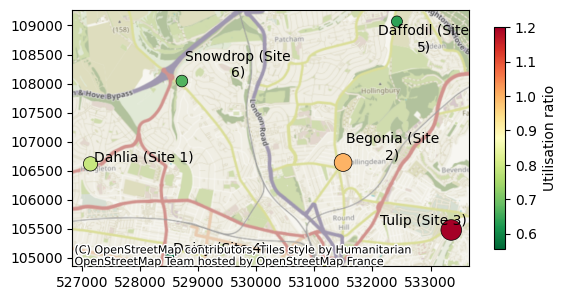

In [ ]:
problem.plot_site_utilisation(add_basemap=True, show_labels=True);

Tulip and Begonia stand out immediately as the largest, reddest markers -- exactly the two sites already flagged above. 

`interactive=True` returns the same map as a Folium map, with a tooltip on every site.

In [6]:
problem.plot_site_utilisation(add_basemap=True, show_labels=True, interactive=True)

## Elsewhere in lokigi

- The [2SFCA example](../accessibility_2sfca/index.ipynb) answers a related but different question -- how much supply is *reachable* given competition from other regions' demand. That's catchment-derived and needs a travel matrix; this notebook's utilisation figures are today's real-world baseline, registered directly on `candidate_sites`.
- `site_allocation_summary()` (see the [comparing N sites example](../comparing_n_sites/index.ipynb)) answers a third, solve-derived question -- how much demand would this site pick up under a chosen solution. `site_utilisation_summary()` has no `SiteSolutionSet` counterpart, since it isn't about any solved solution at all.
- The [evaluating an existing site combination example](../evaluating_current_baseline/index.ipynb) evaluates the current network's *travel* performance (coverage, average travel time); this one evaluates each site's current *load*. The two are complementary baselines for the same "before any changes" story.